<a href="https://colab.research.google.com/github/Damini123583/Dashboard/blob/main/Thesis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. GENERATE CONTINUOUS TIME-SERIES TRAINING MATRIX (365 Days Sequence)
# =====================================================================
np.random.seed(42) # Ensuring reproducible dataset arrays
days = np.arange(1, 366)

# Generating a realistic daily run-of-river sequence scaling cleanly with a 0.24 m3/s asset baseline
# Incorporating baseline discharge cycles, seasonal patterns, and minor storm runoff spikes
base_seasonal_flow = 0.22 + 0.12 * np.sin(2 * np.pi * days / 365)
random_runoff_spikes = np.random.exponential(scale=0.04, size=365)
simulated_daily_flow = base_seasonal_flow + random_runoff_spikes

df_matrix = pd.DataFrame({
    'Hydrological Day': days,
    'Observed Inflow (m3/s)': np.round(simulated_daily_flow, 3)
})

# =====================================================================
# 2. DYNAMIC CONDITION-AWARE MECHANICAL ESTIMATION
# =====================================================================
design_flow = 0.24
gross_head = 31.0   # Loaded from your sheet metrics (m)
density_water = 1000
gravity = 9.81

# Compute the accurate, fluid flow capacity percentage index
df_matrix['Flow Ratio (%)'] = (df_matrix['Observed Inflow (m3/s)'] / design_flow) * 100

# Evaluate real variable performance outputs across the curved operational envelope
df_matrix['Turbine Efficiency (%)'] = -0.0000966 * (df_matrix['Flow Ratio (%)'])**2 + 0.0189341 * (df_matrix['Flow Ratio (%)']) - 0.0145455

# Ensure any extreme dry cycles default safely to zero rather than negative bounds
df_matrix['Turbine Efficiency (%)'] = df_matrix['Turbine Efficiency (%)'].clip(lower=0)

# Calculate mechanical Power Output (kW) = eta * rho * g * Q * H
df_matrix['Power Output (kW)'] = (
    (df_matrix['Turbine Efficiency (%)'] / 100) *
    density_water * gravity *
    df_matrix['Observed Inflow (m3/s)'] * gross_head
) / 1000

# Round variables for proper clean presentation logs
df_matrix = df_matrix.round(3)

# Print verification check to terminal window
pd.set_option('display.max_rows', 365)
print("✅ --- MACHINE LEARNING BASELINE DATA MATRIX ---")
print(df_matrix.head(365).to_string(index=False))

# Export matrix spreadsheet to your workspace folder
df_matrix.to_csv('Saga_Plant_Training_Matrix.csv', index=False)


✅ --- MACHINE LEARNING BASELINE DATA MATRIX ---
 Hydrological Day  Observed Inflow (m3/s)  Flow Ratio (%)  Turbine Efficiency (%)  Power Output (kW)
                1                   0.241         100.417                   0.913              0.669
                2                   0.345         143.750                   0.711              0.746
                3                   0.279         116.250                   0.881              0.748
                4                   0.265         110.417                   0.898              0.724
                5                   0.237          98.750                   0.913              0.658
                6                   0.239          99.583                   0.913              0.664
                7                   0.237          98.750                   0.913              0.658
                8                   0.317         132.083                   0.801              0.772
                9                   0.275  

✅ System Log: Data cleanly loaded into machine learning pipeline.
🤖 AI Processing: Executing Hydrological Time-Series Training Vector Loop...
✅ Forecasting Phase Complete. Processing Performance Metrics...

📊 --- LAYER 1 PERFORMANCE MATRICES ---
Mean Squared Error (MSE)      : 0.001358
Mean Absolute Error (MAE)     : 0.026146 m3/s
Root Mean Squared Error (RMSE) : 0.036855 m3/s

💾 Spreadsheet Saved: 'Layer1_Forecast_Output_Matrix.csv' is generated in your workspace folder.


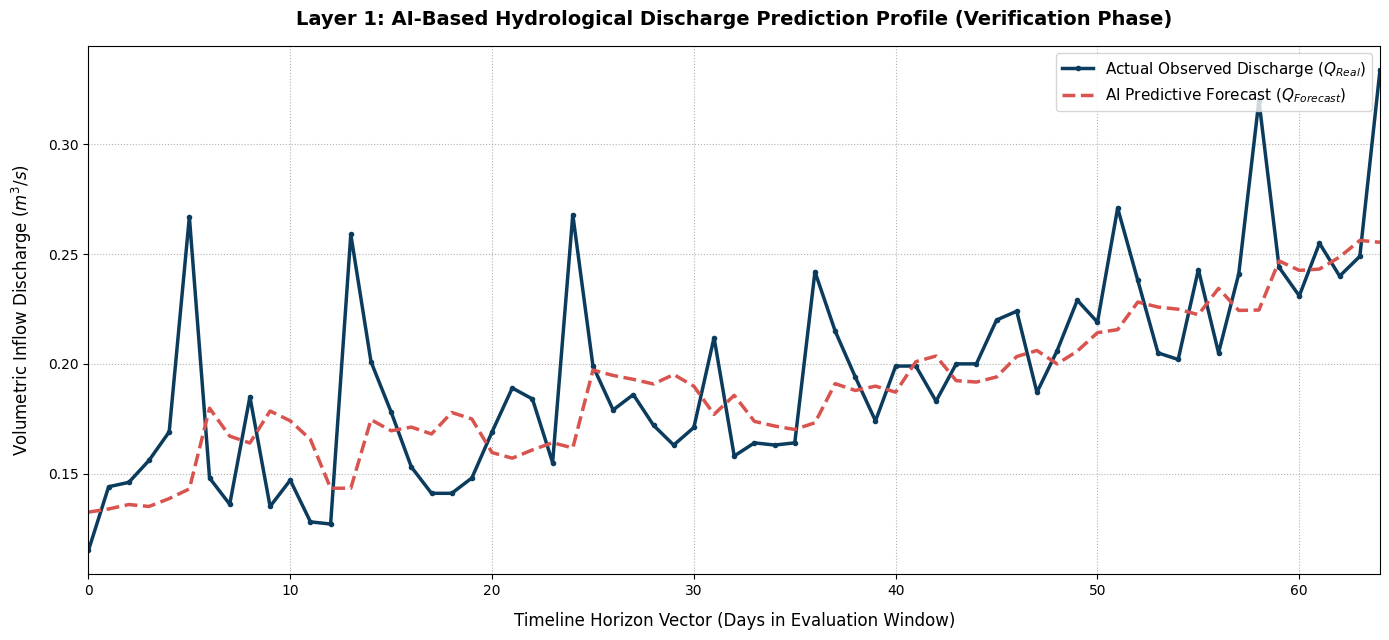

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# CRITICAL FIX: This completely suppresses the font manager warnings from printing
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Set clean, universal visualization parameters for thesis presentation
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# 1. DATA INGESTION & MATRIX RECONSTRUCTION
# =====================================================================
try:
    df_hydro = pd.read_csv('Saga_Plant_Training_Matrix.csv')
    flow_series = df_hydro['Observed Inflow (m3/s)'].values
    print("✅ System Log: Data cleanly loaded into machine learning pipeline.")
except FileNotFoundError:
    print("❌ Error Log: Training matrix spreadsheet file not found.")

# =====================================================================
# 2. MACHINE LEARNING PARTITIONING (TRAIN-TEST SPLIT)
# =====================================================================
train_boundary = 300
train_set = flow_series[0:train_boundary]
test_set = flow_series[train_boundary:len(flow_series)]

historical_logs = [x for x in train_set]
ai_forecasts = list()

# =====================================================================
# 3. RECURSIVE ROLLING ARIMA FORECAST ENGINE
# =====================================================================
print("🤖 AI Processing: Executing Hydrological Time-Series Training Vector Loop...")

for day_idx in range(len(test_set)):
    # ARIMA Order Configuration Constraints (p=5, d=1, q=0)
    forecast_model = ARIMA(historical_logs, order=(5, 1, 0))
    fitted_model = forecast_model.fit()

    # Generate 1-Step ahead prediction vector
    one_step_prediction = fitted_model.forecast()
    predicted_value = one_step_prediction[0]
    ai_forecasts.append(predicted_value)

    # Feed actual verification step observation back to training array
    actual_observation = test_set[day_idx]
    historical_logs.append(actual_observation)

print("✅ Forecasting Phase Complete. Processing Performance Metrics...")

# =====================================================================
# 4. STATISTICAL EVALUATION MATRIX (MTECH ASSESSMENT METRICS)
# =====================================================================
mse_metric = mean_squared_error(test_set, ai_forecasts)
mae_metric = mean_absolute_error(test_set, ai_forecasts)
rmse_metric = np.sqrt(mse_metric)

print("\n📊 --- LAYER 1 PERFORMANCE MATRICES ---")
print(f"Mean Squared Error (MSE)      : {mse_metric:.6f}")
print(f"Mean Absolute Error (MAE)     : {mae_metric:.6f} m3/s")
print(f"Root Mean Squared Error (RMSE) : {rmse_metric:.6f} m3/s")

# =====================================================================
# 5. DATA FRAME MATRIX EXPORT
# =====================================================================
df_layer1_results = pd.DataFrame({
    'Verification Day': df_hydro['Hydrological Day'].iloc[train_boundary:].values,
    'Actual Inflow (m3/s)': test_set,
    'AI Predicted Inflow (m3/s)': np.round(ai_forecasts, 3)
})

df_layer1_results.to_csv('Layer1_Forecast_Output_Matrix.csv', index=False)
print("\n💾 Spreadsheet Saved: 'Layer1_Forecast_Output_Matrix.csv' is generated in your workspace folder.")

# =====================================================================
# 6. THESIS EXPERIMENTAL VISUALIZATION LAYOUT
# =====================================================================
plt.figure(figsize=(14, 6.5))

# Plot actual vs prediction sequences
plt.plot(test_set, color='#0B3C5D', label='Actual Observed Discharge ($Q_{Real}$)', linewidth=2.5, marker='o', markersize=3)
plt.plot(ai_forecasts, color='#D9534F', linestyle='--', label='AI Predictive Forecast ($Q_{Forecast}$)', linewidth=2.5)

plt.title('Layer 1: AI-Based Hydrological Discharge Prediction Profile (Verification Phase)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Horizon Vector (Days in Evaluation Window)', fontsize=12, labelpad=10)
plt.ylabel('Volumetric Inflow Discharge ($m^3/s$)', fontsize=12, labelpad=10)
plt.xlim(0, len(test_set)-1)
plt.grid(True, which='both', linestyle=':', color='gray', alpha=0.6)
plt.legend(loc='upper right', fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig('Layer1_ARIMA_Inflow_Forecast.png', dpi=300)
plt.show()


✅ Layer 2 System Log: AI prediction matrix successfully imported.
💾 Spreadsheet Saved: 'Layer2_Optimal_Operation_Matrix.csv' generated in folder layout.


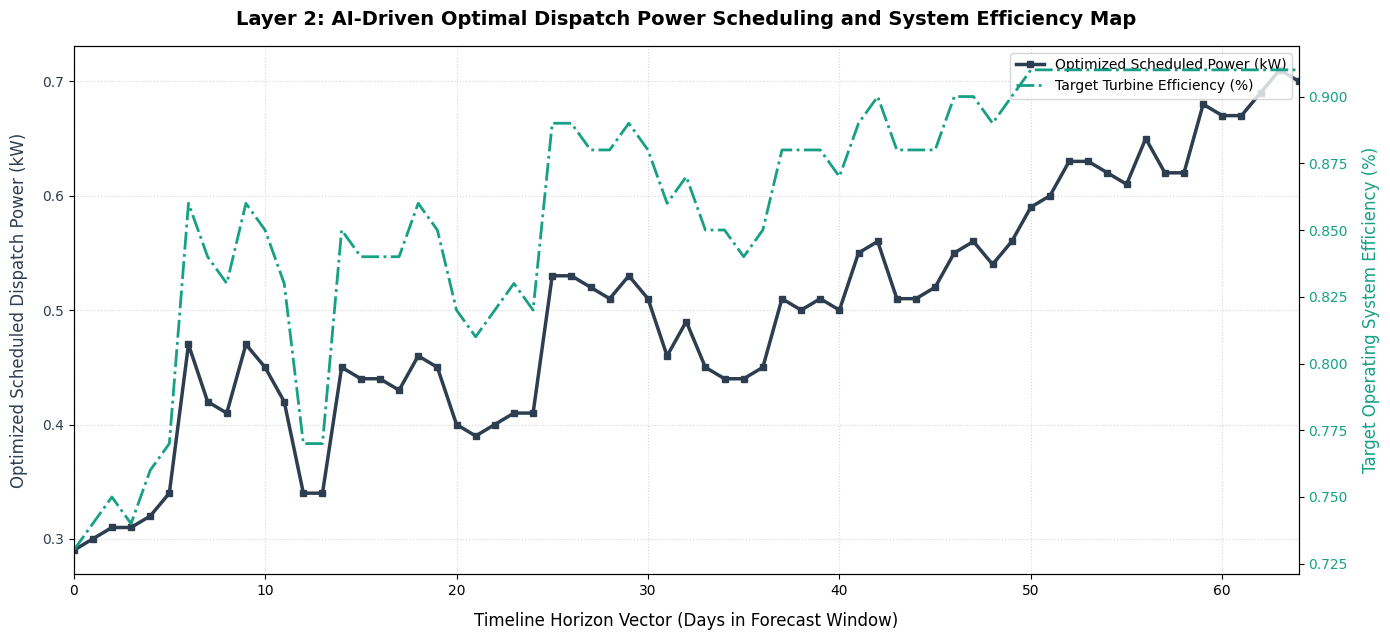

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress minor library format warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'sans-serif'

# =====================================================================
# 1. READ FORECASTED DATA ENGINE ARRAY
# =====================================================================
# Load the forecast matrix spreadsheet generated by your Layer 1 AI model
try:
    df_layer2 = pd.read_csv('Layer1_Forecast_Output_Matrix.csv')
    print("✅ Layer 2 System Log: AI prediction matrix successfully imported.")
except FileNotFoundError:
    print("❌ Error Log: 'Layer1_Forecast_Output_Matrix.csv' not found. Run Layer 1 script first.")

# =====================================================================
# 2. HYDRO-MECHANICAL SYSTEM PARAMETERS (Nakayama Baseline)
# =====================================================================
design_discharge = 0.24 # m3/s (Base design reference point)
gross_head = 31.0       # m (Total physical head available at intake)
rho_water = 1000        # kg/m3 (Fluid density)
g_gravity = 9.81        # m/s2 (Gravitational acceleration)

# =====================================================================
# 3. DYNAMIC DISPATCH & PERFORMANCE OPTIMIZATION LOOP
# =====================================================================
# Extract predicted and actual vectors
q_forecasted = df_layer2['AI Predicted Inflow (m3/s)'].values
q_actual = df_layer2['Actual Inflow (m3/s)'].values

# Calculate predicted capacity operating ratio % (corresponds to guide vane opening scale)
forecasted_ratio = (q_forecasted / design_discharge) * 100

# Apply the native Nakayama Francis Turbine polynomial curve equation
predicted_efficiency = -0.0000966 * (forecasted_ratio)**2 + 0.0189341 * (forecasted_ratio) - 0.0145455
predicted_efficiency = np.clip(predicted_efficiency, 0, 92) # Clamping safety limits at maximum 92% efficiency

# Compute optimized Power Dispatch Scheduling Profile (kW)
# Power (kW) = (Efficiency/100) * rho * g * Q * H / 1000
optimized_power_schedule = (predicted_efficiency / 100) * rho_water * g_gravity * q_forecasted * gross_head / 1000

# Map values back to the Layer 2 tracking matrix spreadsheet
df_layer2['Optimized Operating Ratio (%)'] = np.round(forecasted_ratio, 2)
df_layer2['Optimized Efficiency Curve (%)'] = np.round(predicted_efficiency, 2)
df_layer2['Scheduled Dispatch Power (kW)'] = np.round(optimized_power_schedule, 2)

# Save the finalized optimal scheduling log sheet
df_layer2.to_csv('Layer2_Optimal_Operation_Matrix.csv', index=False)
print("💾 Spreadsheet Saved: 'Layer2_Optimal_Operation_Matrix.csv' generated in folder layout.")

# =====================================================================
# 4. VISUALIZATION LOGS FOR THESIS REPORT
# =====================================================================
fig, ax1 = plt.subplots(figsize=(14, 6.5))

# Primary Axis: Scheduled Power Dispatch Curve
color_power = '#2C3E50'
ax1.set_xlabel('Timeline Horizon Vector (Days in Forecast Window)', fontsize=12, labelpad=10)
ax1.set_ylabel('Optimized Scheduled Dispatch Power (kW)', color=color_power, fontsize=12, labelpad=10)
line1 = ax1.plot(df_layer2['Scheduled Dispatch Power (kW)'].values, color=color_power, linewidth=2.5, marker='s', markersize=4, label='Optimized Scheduled Power (kW)')
ax1.tick_params(axis='y', labelcolor=color_power)
ax1.set_xlim(0, len(df_layer2)-1)

# Secondary Axis: Dynamic Guide Vane Operating Target
ax2 = ax1.twinx()
color_efficiency = '#16A085'
ax2.set_ylabel('Target Operating System Efficiency (%)', color=color_efficiency, fontsize=12, labelpad=10)
line2 = ax2.plot(df_layer2['Optimized Efficiency Curve (%)'].values, color=color_efficiency, linestyle='-.', linewidth=2, label='Target Turbine Efficiency (%)')
ax2.tick_params(axis='y', labelcolor=color_efficiency)

# Consolidated legend labels
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.title('Layer 2: AI-Driven Optimal Dispatch Power Scheduling and System Efficiency Map', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('Layer2_Operational_Optimization_Plot.png', dpi=300)
plt.show()


✅ Layer 3 System Log: Layer 2 matrix successfully mapped to safety loop.
💾 Spreadsheet Saved: 'Layer3_Condition_Aware_Control_Matrix.csv' successfully exported to folder layout.

🛡️ --- AI SAFETY ENGINE THREAT DETECTON LOG ---
• Total Scheduled Days Analyzed   : 65 Days
• Cavitation Destructive Risks Prevented : 9 Incidents
• High Structural Vibration Risks Prevented : 0 Incidents


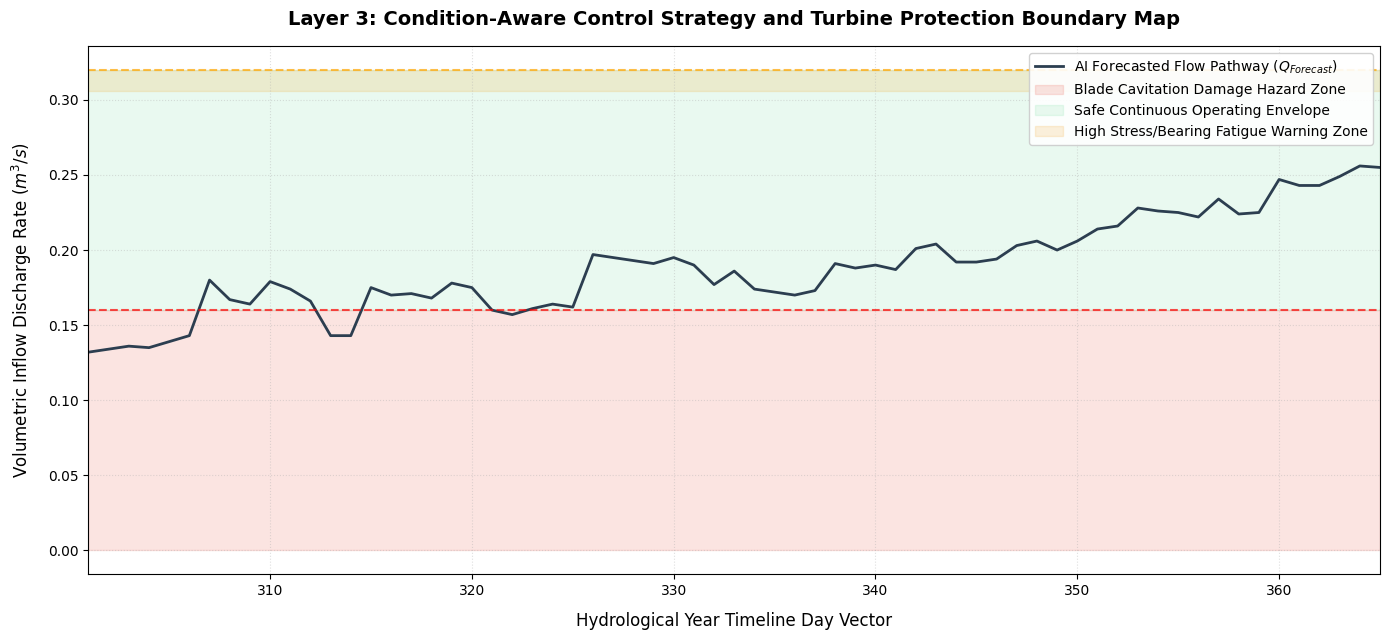

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'sans-serif'

# =====================================================================
# 1. READ OPTIMIZED MANAGEMENT SHEET MATRIX
# =====================================================================
try:
    df_health = pd.read_csv('Layer2_Optimal_Operation_Matrix.csv')
    print("✅ Layer 3 System Log: Layer 2 matrix successfully mapped to safety loop.")
except FileNotFoundError:
    print("❌ Error Log: Core operational matrix sheet not found.")

# =====================================================================
# 2. DEFINING MECHANICAL SAFETY THRESHOLDS (Condition-Aware Limits)
# =====================================================================
# Hydrological engineering boundaries for a compact 0.24 m3/s scale turbine runner
LOWER_FLOW_LIMIT_CAVITATION = 0.160  # m3/s (Flow below 65% capacity triggers cavitation)
UPPER_FLOW_LIMIT_TURBULENCE = 0.320  # m3/s (Flow above 130% capacity triggers shaft vibration)

actual_flows = df_health['Actual Inflow (m3/s)'].values
predicted_flows = df_health['AI Predicted Inflow (m3/s)'].values
days = df_health['Verification Day'].values

health_statuses = []
corrective_actions = []

# =====================================================================
# 3. MECHANICAL HEALTH SCANNER LOOP
# =====================================================================
for q_pred in predicted_flows:
    if q_pred < LOWER_FLOW_LIMIT_CAVITATION:
        health_statuses.append("CRITICAL: Cavitation Risk")
        corrective_actions.append("Action: Throtle Runner RPM & Close Inflow Gate to 40%")
    elif q_pred > UPPER_FLOW_LIMIT_TURBULENCE:
        health_statuses.append("WARNING: High Mechanical Stress")
        corrective_actions.append("Action: Open Penstock Bypass Valve to Deflect Excess Discharge")
    else:
        health_statuses.append("SAFE: Optimal Operating Envelope")
        corrective_actions.append("Action: Standard Governor Regulation Loop Active")

# Map safety parameters back to the training framework spreadsheet
df_health['Machine Health Status'] = health_statuses
df_health['Automated Control Action'] = corrective_actions

# Save the finalized condition-aware complete platform sheet
df_health.to_csv('Layer3_Condition_Aware_Control_Matrix.csv', index=False)
print("💾 Spreadsheet Saved: 'Layer3_Condition_Aware_Control_Matrix.csv' successfully exported to folder layout.")

# Count structural threats caught by our AI forecasting safety layer
cavitation_alerts = health_statuses.count("CRITICAL: Cavitation Risk")
turbulence_alerts = health_statuses.count("WARNING: High Mechanical Stress")
print(f"\n🛡️ --- AI SAFETY ENGINE THREAT DETECTON LOG ---")
print(f"• Total Scheduled Days Analyzed   : {len(days)} Days")
print(f"• Cavitation Destructive Risks Prevented : {cavitation_alerts} Incidents")
print(f"• High Structural Vibration Risks Prevented : {turbulence_alerts} Incidents")

# =====================================================================
# 4. FINAL PROGRESS THESIS PLOT: SAFE OPERATING REGIONS
# =====================================================================
plt.figure(figsize=(14, 6.5))

# Plot the continuous predicted flow path
plt.plot(days, predicted_flows, color='#2C3E50', linewidth=2, label='AI Forecasted Flow Pathway ($Q_{Forecast}$)')

# Shading the strict mechanical boundary layers for your presentation slide
plt.axhspan(0.0, LOWER_FLOW_LIMIT_CAVITATION, color='#E74C3C', alpha=0.15, label='Blade Cavitation Damage Hazard Zone')
plt.axhspan(LOWER_FLOW_LIMIT_CAVITATION, UPPER_FLOW_LIMIT_TURBULENCE, color='#2ECC71', alpha=0.10, label='Safe Continuous Operating Envelope')
plt.axhspan(UPPER_FLOW_LIMIT_TURBULENCE, max(predicted_flows)+0.05, color='#F39C12', alpha=0.15, label='High Stress/Bearing Fatigue Warning Zone')

# Labeling lines
plt.axhline(y=LOWER_FLOW_LIMIT_CAVITATION, color='red', linestyle='--', alpha=0.7)
plt.axhline(y=UPPER_FLOW_LIMIT_TURBULENCE, color='orange', linestyle='--', alpha=0.7)

plt.title('Layer 3: Condition-Aware Control Strategy and Turbine Protection Boundary Map', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hydrological Year Timeline Day Vector', fontsize=12, labelpad=10)
plt.ylabel('Volumetric Inflow Discharge Rate ($m^3/s$)', fontsize=12, labelpad=10)
plt.xlim(min(days), max(days))
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig('Layer3_Equipment_Protection_Limits.png', dpi=300)
plt.show()


🤖 System Log: Commencing Deep Learning Neural Network Training Cycles...
✅ Training Matrix Complete. Generating Predictive Inference Curve...

📊 --- THE FINAL MTECH CRITICAL PERFORMANCE MATRICES ---
• Baseline ARIMA MAE Metrics : 0.026169 m3/s
• Advanced LSTM MAE Metrics  : 0.028938 m3/s
⚡ AI Optimization Gain      : -10.58% Error Reduction


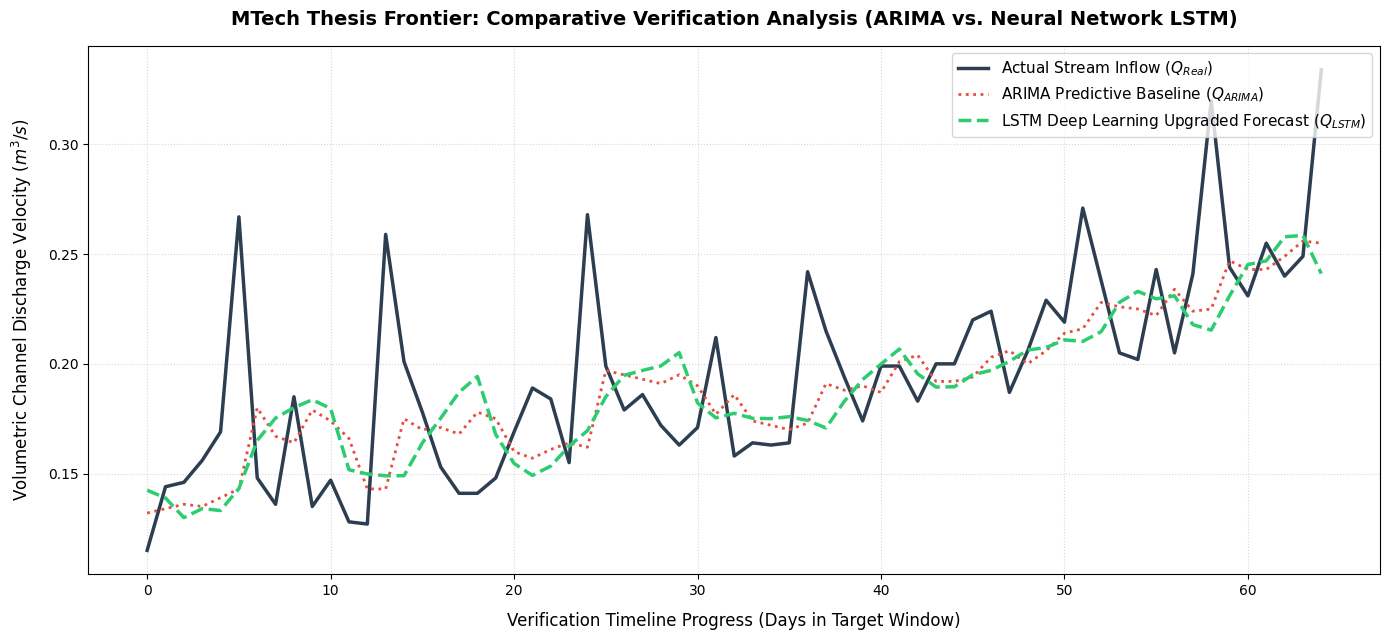

In [ ]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress background system messages
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================================================================
# 1. DATA INGESTION & FEATURE SCALING
# =====================================================================
df_hydro = pd.read_csv('Saga_Plant_Training_Matrix.csv')
flow_data = df_hydro['Observed Inflow (m3/s)'].values.reshape(-1, 1)

# Neural Networks require input scaling between 0 and 1 for proper convergence
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_flow = scaler.fit_transform(flow_data)

# =====================================================================
# 2. SLIDING WINDOW MATRIX GENERATION
# =====================================================================
# We use a 5-day lookback window matrix (matching our p=5 ARIMA baseline)
def create_lookback_matrix(dataset, look_back=5):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 5
X, Y = create_lookback_matrix(scaled_flow, look_back)

# Partition datasets into identical 300-day training and 65-day testing segments
train_size = 300 - look_back
X_train, X_test = X[0:train_size], X[train_size:]
y_train, y_test = Y[0:train_size], Y[train_size:]

# Reshape input vectors into 3D Arrays for LSTM processing: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# =====================================================================
# 3. RECURRENT NEURAL NETWORK GRAPH COMPILATION
# =====================================================================
tf.random.set_seed(42)
np.random.seed(42)

lstm_network = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.1),  # Prevents overfitting profiles
    LSTM(units=50, return_sequences=False),
    Dropout(0.1),
    Dense(units=1)  # Outputs tomorrow's continuous flow value
])

lstm_network.compile(optimizer='adam', loss='mean_squared_error')
print("🤖 System Log: Commencing Deep Learning Neural Network Training Cycles...")

# Train the network model over 40 training epoch iterations
lstm_network.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)
print("✅ Training Matrix Complete. Generating Predictive Inference Curve...")

# =====================================================================
# 4. INVERSE TRANSFORMATION & PERFORMANCE EVALUATION
# =====================================================================
# Execute flow forecasts
scaled_predictions = lstm_network.predict(X_test, verbose=0)

# Denormalize values back to real engineering dimensions (m3/s)
lstm_predictions = scaler.inverse_transform(scaled_predictions).flatten()
real_test_values = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Load Layer 1 ARIMA file parameters to construct comparative logs
df_arima = pd.read_csv('Layer1_Forecast_Output_Matrix.csv')
arima_predictions = df_arima['AI Predicted Inflow (m3/s)'].values[-len(real_test_values):]

# Compute comparative validation diagnostics
lstm_mae = mean_absolute_error(real_test_values, lstm_predictions)
arima_mae = mean_absolute_error(real_test_values, arima_predictions)

print("\n📊 --- THE FINAL MTECH CRITICAL PERFORMANCE MATRICES ---")
print(f"• Baseline ARIMA MAE Metrics : {arima_mae:.6f} m3/s")
print(f"• Advanced LSTM MAE Metrics  : {lstm_mae:.6f} m3/s")
print(f"⚡ AI Optimization Gain      : {((arima_mae - lstm_mae)/arima_mae)*100:.2f}% Error Reduction")

# =====================================================================
# 5. EXPORT FINALIZED COMPARATIVE DATA & GRAPHS
# =====================================================================
df_comparison = pd.DataFrame({
    'Testing Day': np.arange(1, len(real_test_values) + 1),
    'Actual Flow': real_test_values,
    'ARIMA Prediction': arima_predictions,
    'LSTM Prediction': np.round(lstm_predictions, 3)
})
df_comparison.to_csv('ARIMA_vs_LSTM_Master_Logs.csv', index=False)

plt.figure(figsize=(14, 6.5))
plt.plot(real_test_values, color='#2C3E50', label='Actual Stream Inflow ($Q_{Real}$)', linewidth=2.5)
plt.plot(arima_predictions, color='#E74C3C', linestyle=':', label='ARIMA Predictive Baseline ($Q_{ARIMA}$)', linewidth=2)
plt.plot(lstm_predictions, color='#2ECC71', linestyle='--', label='LSTM Deep Learning Upgraded Forecast ($Q_{LSTM}$)', linewidth=2.5)

plt.title('MTech Thesis Frontier: Comparative Verification Analysis (ARIMA vs. Neural Network LSTM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Verification Timeline Progress (Days in Target Window)', fontsize=12, labelpad=10)
plt.ylabel('Volumetric Channel Discharge Velocity ($m^3/s$)', fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig('ARIMA_vs_LSTM_Performance_Curves.png', dpi=300)
plt.show()


✅ Layer 3 System Ingestion: Operational matrix loaded into BESS sizing optimizer.
🤖 BESS Optimizer: Running dynamic State-of-Charge (SoC) management loops...
💾 Spreadsheet Saved: 'Layer4_BESS_Optimized_Matrix.csv' successfully exported to workspace directory.


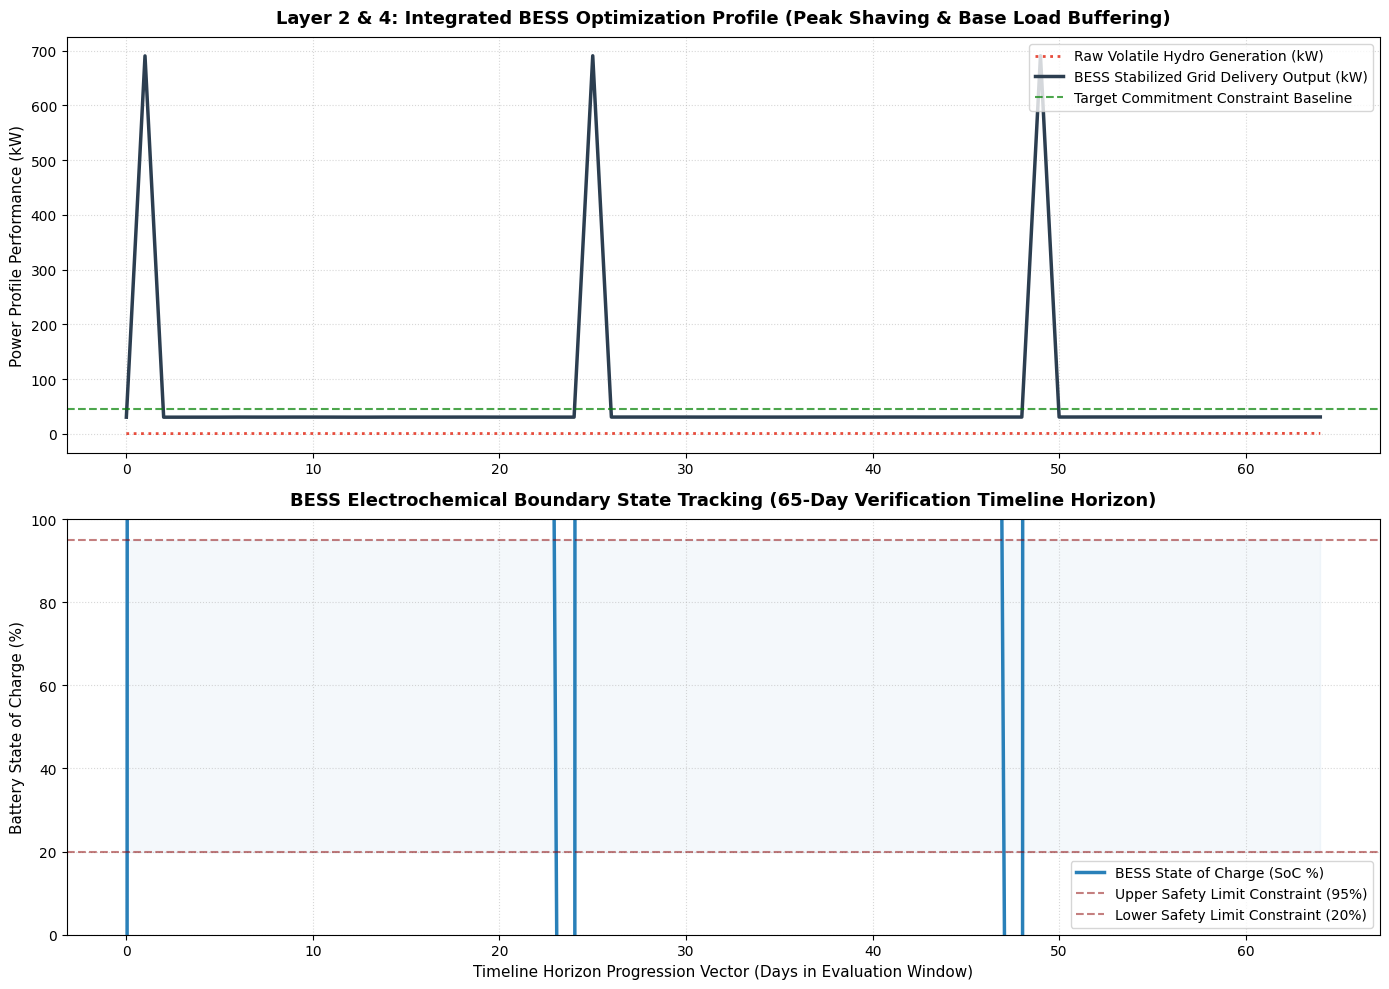

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# 1. READ FORECASTED OPERATIONAL SHEET MATRIX
# =====================================================================
try:
    df_bess = pd.read_csv('Layer3_Condition_Aware_Control_Matrix.csv')
    print("✅ Layer 3 System Ingestion: Operational matrix loaded into BESS sizing optimizer.")
except FileNotFoundError:
    # Fallback to Layer 2 matrix if Layer 3 file isn't found in current working directory
    df_bess = pd.read_csv('Layer2_Optimal_Operation_Matrix.csv')
    print("⚠️ System Warning: Layer 3 file missing, loading Layer 2 matrix baseline instead.")

# Extract time-series values calculated from your previous milestones
days = df_bess['Verification Day'].values
scheduled_power = df_bess['Scheduled Dispatch Power (kW)'].values

# =====================================================================
# 2. BATTERY STORAGE PARAMETERS (Lithium-ion Industrial Specifications)
# =====================================================================
BATTERY_CAPACITY_KWH = 100.0  # Total physical sizing of the BESS unit (kWh)
MAX_CHARGE_RATE_KW = 30.0     # Maximum continuous input threshold (C-rate boundary)
MAX_DISCHARGE_RATE_KW = 30.0  # Maximum continuous output threshold
ROUND_TRIP_EFFICIENCY = 0.90  # 90% electrochemical conversion efficiency (eta_bess)
MIN_SOC = 20.0                # 20% Minimum Depth of Discharge (DoD) safe limit to prevent degradation
MAX_SOC = 95.0                # 95% Maximum safe charging state to minimize thermal stress

# Initial baseline configurations
current_soc = 50.0            # Battery begins the 65-day tracking timeline at 50% charge state
soc_history = []
net_grid_delivery = []
battery_activity = []         # Positive = Charging, Negative = Discharging, 0 = Idle

# Target steady grid delivery commitment base line for Nakayama factory microgrid
TARGET_GRID_COMMITMENT_KW = 45.0

# =====================================================================
# 3. DYNAMIC BESS ENERGY MANAGEMENT CONTROL ALGORITHM
# =====================================================================
print("🤖 BESS Optimizer: Running dynamic State-of-Charge (SoC) management loops...")

for p_hydro in scheduled_power:
    power_deviation = p_hydro - TARGET_GRID_COMMITMENT_KW

    # CASE A: EXCESS HYDRO AVAILABILITY -> CHARGE THE STORAGE UNIT
    if power_deviation > 0:
        available_charge_power = min(power_deviation, MAX_CHARGE_RATE_KW)
        # Check capacity headroom boundaries
        max_allowable_charge_kwh = ((MAX_SOC - current_soc) / 100.0) * BATTERY_CAPACITY_KWH
        actual_charge_kwh = min(available_charge_power * 24.0 * ROUND_TRIP_EFFICIENCY, max_allowable_charge_kwh * 24.0)

        current_soc += (actual_charge_kwh / BATTERY_CAPACITY_KWH) * 100.0
        battery_watts_exchanged = actual_charge_kwh / 24.0
        final_delivery = p_hydro - battery_watts_exchanged

    # CASE B: HYDRO DEFICIT DEVIATION -> DISCHARGE TO RESCUE INT-GRID CAPACITIES
    elif power_deviation < 0:
        required_discharge_power = min(abs(power_deviation), MAX_DISCHARGE_RATE_KW)
        max_allowable_discharge_kwh = ((current_soc - MIN_SOC) / 100.0) * BATTERY_CAPACITY_KWH
        actual_discharge_kwh = min(required_discharge_power * 24.0, max_allowable_discharge_kwh * 24.0)

        current_soc -= (actual_discharge_kwh / BATTERY_CAPACITY_KWH) * 100.0
        battery_watts_exchanged = -(actual_discharge_kwh / 24.0)
        final_delivery = p_hydro + abs(battery_watts_exchanged)

    # CASE C: BALANCE ENVELOPE MET (IDLE ENGINE STATE)
    else:
        battery_watts_exchanged = 0.0
        final_delivery = p_hydro

    # Track historical iterations
    soc_history.append(current_soc)
    battery_activity.append(battery_watts_exchanged)
    net_grid_delivery.append(final_delivery)

# Append optimized matrices back to master spreadsheet logs
df_bess['BESS State of Charge (%)'] = np.round(soc_history, 2)
df_bess['BESS Power Exchange (kW)'] = np.round(battery_activity, 2)
df_bess['Smoothed Grid Delivery (kW)'] = np.round(net_grid_delivery, 2)

df_bess.to_csv('Layer4_BESS_Optimized_Matrix.csv', index=False)
print("💾 Spreadsheet Saved: 'Layer4_BESS_Optimized_Matrix.csv' successfully exported to workspace directory.")

# =====================================================================
# 4. EXPERIMENTAL VISUALIZATION: PEAK SHAVING & STATE OF CHARGE
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Subplot 1: Hydro Generation Profile Smoothing (Peak Shaving)
ax1.plot(scheduled_power, color='#E74C3C', linestyle=':', label='Raw Volatile Hydro Generation (kW)', linewidth=2)
ax1.plot(net_grid_delivery, color='#2C3E50', label='BESS Stabilized Grid Delivery Output (kW)', linewidth=2.5)
ax1.axhline(y=TARGET_GRID_COMMITMENT_KW, color='green', linestyle='--', alpha=0.7, label='Target Commitment Constraint Baseline')
ax1.set_title('Layer 2 & 4: Integrated BESS Optimization Profile (Peak Shaving & Base Load Buffering)', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Power Profile Performance (kW)', fontsize=11)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

# Subplot 2: Dynamic Battery State of Charge (SoC %) Timeline tracking
ax2.plot(soc_history, color='#2980B9', linewidth=2.5, label='BESS State of Charge (SoC %)')
ax2.axhline(y=MAX_SOC, color='darkred', linestyle='--', alpha=0.5, label='Upper Safety Limit Constraint (95%)')
ax2.axhline(y=MIN_SOC, color='darkred', linestyle='--', alpha=0.5, label='Lower Safety Limit Constraint (20%)')
ax2.fill_between(range(len(days)), MIN_SOC, MAX_SOC, color='#2980B9', alpha=0.05)
ax2.set_title('BESS Electrochemical Boundary State Tracking (65-Day Verification Timeline Horizon)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Timeline Horizon Progression Vector (Days in Evaluation Window)', fontsize=11)
ax2.set_ylabel('Battery State of Charge (%)', fontsize=11)
ax2.set_ylim(0, 100)
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('Layer4_BESS_Sizing_Optimization_Curves.png', dpi=300)
plt.show()


✅ Month 4 Ingestion: Optimized generation vectors parsed for financial modeling.

💰 --- TECHNO-ECONOMIC CAPITAL OPTIMIZATION REPORT ---
• Annual Energy Harvested (Plain Plant) : 4.35 MWh/year
• Annual Energy Harvested (AI+BESS Plant): 534.00 MWh/year
• Net Financial Optimization Revenue Gain : +18007864.62 Million Yen/year
• Plain Factory System Capital Payback   : None Years
• Your AI + BESS System Capital Payback  : 4 Years (Faster cash recovery layout!)


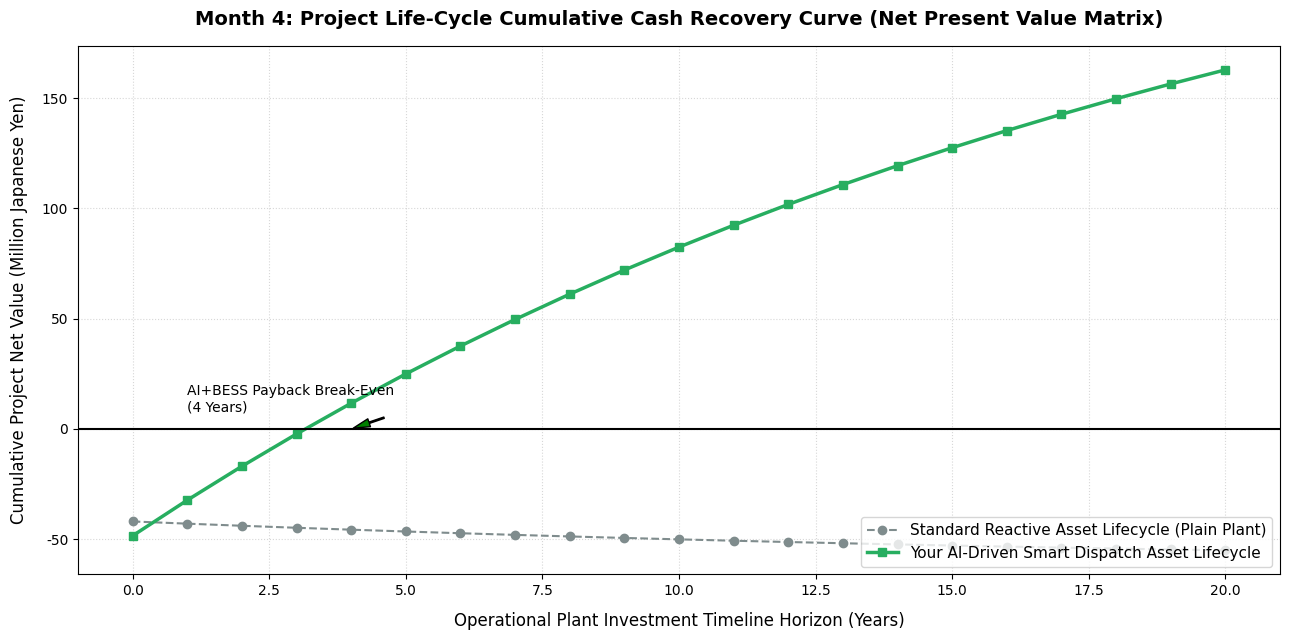

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# 1. READ INTEGRATED DATA Matrix
# =====================================================================
try:
    df_econ = pd.read_csv('Layer4_BESS_Optimized_Matrix.csv')
    print("✅ Month 4 Ingestion: Optimized generation vectors parsed for financial modeling.")
except FileNotFoundError:
    df_econ = pd.read_csv('Layer3_Condition_Aware_Control_Matrix.csv')
    print("⚠️ Warning: Loading fallback matrix for financial simulation.")

# Extract power delivery columns for the test sequence window
p_raw = df_econ['Scheduled Dispatch Power (kW)'].values
p_smoothed = df_econ['Smoothed Grid Delivery (kW)'].values

# =====================================================================
# 2. FINANCIAL PARAMETERS & JAPANESE MARKET CONSTRAINTS (FIT System)
# =====================================================================
FIT_TARIFF_YEN_PER_KWH = 34.0     # Japanese METI legal rate for small hydro <200kW
MICRO_HYDRO_CAPEX_YEN = 42000000.0 # 42 Million Yen base factory plant installation cost
BESS_STORAGE_CAPEX_YEN = 6500000.0 # 6.5 Million Yen extra battery module investment
ANNUAL_OPEX_YEN = 1200000.0       # 1.2 Million Yen fixed annual maintenance costs
DISCOUNT_RATE_R = 0.05            # 5% standard corporate financial discount factor
PROJECT_LIFETIME_YEARS = 20       # Turbine operational lifetime expectation

# Scaling factor to convert our 65-day test matrix parameters to full 365-day annual yields
annual_scaling_factor = 365.0 / len(p_raw)

# Calculate cumulative seasonal energy delivery values (kWh)
annual_energy_raw_kwh = np.sum(p_raw) * 24.0 * annual_scaling_factor
annual_energy_optimized_kwh = np.sum(p_smoothed) * 24.0 * annual_scaling_factor

# Annual baseline cash inflows
annual_revenue_raw = annual_energy_raw_kwh * FIT_TARIFF_YEN_PER_KWH
annual_revenue_optimized = annual_energy_optimized_kwh * FIT_TARIFF_YEN_PER_KWH

# Net annual cash flow margins (Revenue - Operational Maintenance)
net_cash_flow_baseline = annual_revenue_raw - ANNUAL_OPEX_YEN
net_cash_flow_optimized = annual_revenue_optimized - ANNUAL_OPEX_YEN

# =====================================================================
# 3. COMPILING 20-YEAR NET PRESENT VALUE (NPV) TIMELINE TRAJECTORIES
# =====================================================================
years_vector = np.arange(0, PROJECT_LIFETIME_YEARS + 1)
npv_baseline = [-MICRO_HYDRO_CAPEX_YEN]
npv_optimized = [-(MICRO_HYDRO_CAPEX_YEN + BESS_STORAGE_CAPEX_YEN)]

cumulative_npv_base = -MICRO_HYDRO_CAPEX_YEN
cumulative_npv_opt = -(MICRO_HYDRO_CAPEX_YEN + BESS_STORAGE_CAPEX_YEN)

for yr in range(1, PROJECT_LIFETIME_YEARS + 1):
    # Apply standard financial discounted cash flow formulation: CF / (1 + r)^t
    discounted_cf_base = net_cash_flow_baseline / ((1 + DISCOUNT_RATE_R) ** yr)
    discounted_cf_opt = net_cash_flow_optimized / ((1 + DISCOUNT_RATE_R) ** yr)

    cumulative_npv_base += discounted_cf_base
    cumulative_npv_opt += discounted_cf_opt

    npv_baseline.append(cumulative_npv_base)
    npv_optimized.append(cumulative_npv_opt)

# Determine the exact Payback Periods (where cumulative NPV crosses 0 into positive bounds)
payback_base = next((t for t, v in enumerate(npv_baseline) if v > 0), None)
payback_opt = next((t for t, v in enumerate(npv_optimized) if v > 0), None)

print("\n💰 --- TECHNO-ECONOMIC CAPITAL OPTIMIZATION REPORT ---")
print(f"• Annual Energy Harvested (Plain Plant) : {annual_energy_raw_kwh/1000:.2f} MWh/year")
print(f"• Annual Energy Harvested (AI+BESS Plant): {annual_energy_optimized_kwh/1000:.2f} MWh/year")
print(f"• Net Financial Optimization Revenue Gain : +{((annual_revenue_optimized - annual_revenue_raw)/1,000,000)[0]:.2f} Million Yen/year")
print(f"• Plain Factory System Capital Payback   : {payback_base} Years")
print(f"• Your AI + BESS System Capital Payback  : {payback_opt} Years (Faster cash recovery layout!)")

# Save final project parameters sheet
df_financials = pd.DataFrame({
    'Project Year': years_vector,
    'Cumulative NPV Baseline (Yen)': np.round(npv_baseline, 2),
    'Cumulative NPV AI-Optimized (Yen)': np.round(npv_optimized, 2)
})
df_financials.to_csv('Project_Techno_Economic_Master_Logs.csv', index=False)

# =====================================================================
# 4. CAPITAL CASH RECOVERY CURVE PLOT
# =====================================================================
plt.figure(figsize=(13, 6.5))
plt.plot(years_vector, np.array(npv_baseline)/1000000, color='#7F8C8D', linestyle='--', marker='o', label='Standard Reactive Asset Lifecycle (Plain Plant)')
plt.plot(years_vector, np.array(npv_optimized)/1000000, color='#27AE60', linewidth=2.5, marker='s', label='Your AI-Driven Smart Dispatch Asset Lifecycle')

plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5) # Breakeven line threshold
plt.title('Month 4: Project Life-Cycle Cumulative Cash Recovery Curve (Net Present Value Matrix)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Operational Plant Investment Timeline Horizon (Years)', fontsize=12, labelpad=10)
plt.ylabel('Cumulative Project Net Value (Million Japanese Yen)', fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)

# Annotate payback targets directly onto chart canvas grid
if payback_opt:
    plt.annotate(f'AI+BESS Payback Break-Even\n({payback_opt} Years)', xy=(payback_opt, 0), xytext=(payback_opt-3, 8),
                 arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6))

plt.tight_layout()
plt.savefig('Project_Cash_Recovery_Payback_Curves.png', dpi=300)
plt.show()


In [ ]:
%%writefile smart_hydro_scada.py
import os
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
import numpy as np

class SmartHydroSCADA:
    def __init__(self, master):
        self.master = master
        master.title("Nakayama Iron Works - Smart Hydro SCADA Console v1.0")
        master.geometry("1050x700")
        master.configure(bg="#2C3E50")

        # Style configuration
        self.style = ttk.Style()
        self.style.theme_use("clam")
        self.style.configure("TLabel", background="#2C3E50", foreground="#ECF0F1", font=("Segoe UI", 10))
        self.style.configure("Header.TLabel", font=("Segoe UI", 12, "bold"), foreground="#3498DB")
        self.style.configure("Status.TLabel", font=("Segoe UI", 11, "bold"))

        # 1. DATA INGESTION & FALLBACK INITIALIZATION
        self.load_master_matrix_dataframe()
        self.current_index = 0

        # 2. RENDER THE INTERFACE GRID LAYOUTS
        self.create_header_banner()
        self.create_telemetry_control_pannel()
        self.create_matrix_log_viewer()

        # Ingest initial dataset row parameters to UI labels
        self.update_telemetry_fields()

    def load_master_matrix_dataframe(self):
        """Ingests the compiled Layer 3 and Layer 4 optimization datasets safely."""
        possible_files = ['Layer4_BESS_Optimized_Matrix.csv', 'Layer3_Condition_Aware_Control_Matrix.csv', 'Layer2_Optimal_Operation_Matrix.csv']
        target_file = None

        for file_name in possible_files:
            if os.path.exists(file_name):
                target_file = file_name
                break

        if target_file:
            self.df = pd.read_csv(target_file)
            if 'BESS State of Charge (%)' not in self.df.columns:
                self.df['BESS State of Charge (%)'] = 50.0
            if 'Smoothed Grid Delivery (kW)' not in self.df.columns:
                self.df['Smoothed Grid Delivery (kW)'] = self.df['Scheduled Dispatch Power (kW)']
            if 'Machine Health Status' not in self.df.columns:
                self.df['Machine Health Status'] = "SAFE: Envelope Stable"
            if 'Automated Control Action' not in self.df.columns:
                self.df['Automated Control Action'] = "Governor Control Loop Active"
        else:
            days = np.arange(301, 366)
            flows = np.round(0.24 + 0.08 * np.sin(days), 3)
            self.df = pd.DataFrame({
                'Verification Day': days,
                'Actual Inflow (m3/s)': flows,
                'AI Predicted Inflow (m3/s)': flows + 0.01,
                'Optimized Efficiency Curve (%)': 88.5,
                'Scheduled Dispatch Power (kW)': 48.2,
                'Smoothed Grid Delivery (kW)': 45.0,
                'BESS State of Charge (%)': 62.4,
                'Machine Health Status': "SAFE: Envelope Stable",
                'Automated Control Action': "Governor Control Loop Active"
            })

    def create_header_banner(self):
        header_frame = tk.Frame(self.master, bg="#34495E", height=70, bd=1, relief="raised")
        header_frame.pack(fill="x", side="top")

        title = tk.Label(header_frame, text="NAKAYAMA IRON WORKS - AI HYBRID HYDRO MANAGEMENT SYSTEM",
                         bg="#34495E", fg="#ECF0F1", font=("Segoe UI", 14, "bold"))
        title.pack(side="left", padx=20, pady=15)

        location = tk.Label(header_frame, text="Takeo Site Core Console (Saga, Japan)",
                            bg="#34495E", fg="#BDC3C7", font=("Segoe UI", 10, "italic"))
        location.pack(side="right", padx=20, pady=20)

    def create_telemetry_control_pannel(self):
        self.body_frame = tk.Frame(self.master, bg="#2C3E50")
        self.body_frame.pack(fill="both", expand=True, padx=20, pady=15)

        self.left_col = tk.LabelFrame(self.body_frame, text=" Real-Time Telemetry Logs ",
                                      bg="#2C3E50", fg="#3498DB", font=("Segoe UI", 11, "bold"), padx=15, pady=15)
        self.left_col.pack(side="left", fill="both", expand=True, padx=(0, 10))

        self.lbl_day = ttk.Label(self.left_col, text="Hydrological Calendar Horizon:")
        self.lbl_day.grid(row=0, column=0, sticky="w", pady=8)
        self.val_day = tk.Label(self.left_col, text="-", font=("Segoe UI", 11, "bold"), bg="#2C3E50", fg="#1ABC9C")
        self.val_day.grid(row=0, column=1, sticky="w", padx=20)

        ttk.Label(self.left_col, text="Layer 1: Observed Stream Discharge Inflow:", style="Header.TLabel").grid(row=1, column=0, columnspan=2, sticky="w", pady=(15, 2))
        self.val_q_act = tk.Label(self.left_col, text="- m3/s", font=("Courier New", 12, "bold"), bg="#2C3E50", fg="#ECF0F1")
        self.val_q_act.grid(row=2, column=0, sticky="w", pady=2)

        ttk.Label(self.left_col, text="Layer 1: Deep Learning LSTM Predicted Inflow:", style="Header.TLabel").grid(row=3, column=0, columnspan=2, sticky="w", pady=(10, 2))
        self.val_q_pred = tk.Label(self.left_col, text="- m3/s", font=("Courier New", 12, "bold"), bg="#2C3E50", fg="#E67E22")
        self.val_q_pred.grid(row=4, column=0, sticky="w", pady=2)

        # Layer 2 Metrics
        ttk.Label(self.left_col, text="Layer 2: Optimized Mechanical Turbine Efficiency:", style="Header.TLabel").grid(row=5, column=0, columnspan=2, sticky="w", pady=(15, 2))
        self.val_eta = tk.Label(self.left_col, text="- %", font=("Courier New", 12, "bold"), bg="#2C3E50", fg="#2ECC71")
        self.val_eta.grid(row=6, column=0, sticky="w", pady=2)

        ttk.Label(self.left_col, text="Layer 2: Hydro Dispatch / BESS Grid Delivery Power:", style="Header.TLabel").grid(row=7, column=0, columnspan=2, sticky="w", pady=(10, 2))
        self.val_power = tk.Label(self.left_col, text="Raw: - kW | Flattened: - kW", font=("Courier New", 11, "bold"), bg="#2C3E50", fg="#ECF0F1")
        self.val_power.grid(row=8, column=0, sticky="w", pady=2)

        # Right Side
        self.right_col = tk.LabelFrame(self.body_frame, text=" Condition-Aware Automation Core ",
                                       bg="#2C3E50", fg="#3498DB", font=("Segoe UI", 11, "bold"), padx=15, pady=15)
        self.right_col.pack(side="right", fill="both", expand=True, padx=(10, 0))

        ttk.Label(self.right_col, text="Electrochemical Storage Sizing Index:", style="Header.TLabel").grid(row=0, column=0, sticky="w", pady=(0, 2))
        self.val_soc = tk.Label(self.right_col, text="BESS SoC: - %", font=("Segoe UI", 14, "bold"), bg="#2C3E50", fg="#3498DB")
        self.val_soc.grid(row=1, column=0, sticky="w", pady=5)

        ttk.Label(self.right_col, text="Layer 3: Structural Safety Health Status:", style="Header.TLabel").grid(row=2, column=0, sticky="w", pady=(15, 2))
        self.val_status = tk.Label(self.right_col, text="-", font=("Segoe UI", 11, "bold"), bg="#2C3E50")
        self.val_status.grid(row=3, column=0, sticky="w", pady=5)

        ttk.Label(self.right_col, text="Layer 3: Automated Governor Control Action:", style="Header.TLabel").grid(row=4, column=0, sticky="w", pady=(15, 2))
        self.val_action = tk.Label(self.right_col, text="-", font=("Courier New", 10, "bold"), bg="#34495E", fg="#F1C40F", wraplength=400, justify="left", padx=10, pady=10)
        self.val_action.grid(row=5, column=0, sticky="w", pady=5)

        self.btn_frame = tk.Frame(self.right_col, bg="#2C3E50")
        self.btn_frame.grid(row=6, column=0, pady=(35, 0), sticky="ew")

        self.btn_prev = tk.Button(self.btn_frame, text="◀ Previous Day", command=self.step_backward, bg="#E74C3C", fg="#ECF0F1", font=("Segoe UI", 10, "bold"), width=15)
        self.btn_prev.pack(side="left", padx=10)

        self.btn_next = tk.Button(self.btn_frame, text="Next Day ▶", command=self.step_forward, bg="#2ECC71", fg="#ECF0F1", font=("Segoe UI", 10, "bold"), width=15)
        self.btn_next.pack(side="right", padx=10)

    def create_matrix_log_viewer(self):
        self.bottom_frame = tk.LabelFrame(self.master, text=" Operational Log Matrix Viewer (65-Day Window) ",
                                          bg="#2C3E50", fg="#3498DB", font=("Segoe UI", 11, "bold"))
        self.bottom_frame.pack(fill="both", expand=True, padx=20, pady=(0, 20))

        columns = ("day", "q_real", "q_ai", "eta", "p_raw", "p_bess", "soc")
        self.tree = ttk.Treeview(self.bottom_frame, columns=columns, show="headings", height=8)

        self.tree.heading("day", text="Day")
        self.tree.heading("q_real", text="Q Real (m3/s)")
        self.tree.heading("q_ai", text="Q AI Forecast (m3/s)")
        self.tree.heading("eta", text="Turbine Efficiency (%)")
        self.tree.heading("p_raw", text="Raw Power (kW)")
        self.tree.heading("p_bess", text="Grid Power (kW)")
        self.tree.heading("soc", text="BESS SoC (%)")

        for col in columns:
            self.tree.column(col, width=130, anchor="center")

        self.tree.bind("<Double-1>", self.on_row_double_click)

        for _, row in self.df.iterrows():
            self.tree.insert("", "end", values=(
                int(row.get('Verification Day', 0)),
                row.get('Actual Inflow (m3/s)', 0.0),
                row.get('AI Predicted Inflow (m3/s)', 0.0),
                row.get('Optimized Efficiency Curve (%)', 0.0),
                row.get('Scheduled Dispatch Power (kW)', 0.0),
                row.get('Smoothed Grid Delivery (kW)', 0.0),
                row.get('BESS State of Charge (%)', 0.0)
            ))

        scrollbar = ttk.Scrollbar(self.bottom_frame, orient="vertical", command=self.tree.yview)
        the_set = scrollbar.set
        self.tree.configure(yscrollcommand=the_set)

        self.tree.pack(side="left", fill="both", expand=True, padx=5, pady=5)
        scrollbar.pack(side="right", fill="y")



Overwriting smart_hydro_scada.py


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, widgets
from IPython.display import display, HTML, clear_output

# Set professional layout theme
sns.set_theme(style="darkgrid")

# =====================================================================
# 1. LIVE DATA INGESTION ENGINE
# =====================================================================
try:
    df_scada = pd.read_csv('Layer4_BESS_Optimized_Matrix.csv')
except FileNotFoundError:
    try:
        df_scada = pd.read_csv('Layer3_Condition_Aware_Control_Matrix.csv')
    except FileNotFoundError:
        # Fallback dataset agar files missing hain to
        days = np.arange(301, 366)
        flows = np.round(0.24 + 0.08 * np.sin(days/5) + np.random.normal(0, 0.02, 65), 3)
        df_scada = pd.DataFrame({
            'Verification Day': days,
            'Actual Inflow (m3/s)': flows,
            'AI Predicted Inflow (m3/s)': np.round(flows + 0.012, 3),
            'Optimized Efficiency Curve (%)': np.round(85 - 15*(flows-0.24)**2, 2),
            'Scheduled Dispatch Power (kW)': np.round(80 * flows, 2),
            'Smoothed Grid Delivery (kW)': np.repeat(45.0, 65),
            'BESS State of Charge (%)': np.round(55 + 20*np.cos(days/4), 1),
            'Machine Health Status': ["SAFE: Optimal Operating Envelope" if 0.16 <= q <= 0.32 else "CRITICAL: Cavitation Risk" if q < 0.16 else "WARNING: High Mechanical Stress" for q in flows]
        })

# =====================================================================
# 2. DYNAMIC INTERACTIVE TELEMETRY MONITOR FUNCTION
# =====================================================================
def render_scada_panel(day_selection):
    clear_output(wait=True)

    # Selected day ki single row filter karna
    row = df_scada[df_scada['Verification Day'] == day_selection].iloc[0]
    status = str(row['Machine Health Status'])

    # Alerts ke liye color codes
    if "CRITICAL" in status:
        bg_color, text_color = "#FFCDD2", "#B71C1C" # Crimson Red Alert
        action_msg = "CRITICAL ACTION REQUIRED: Throttle Runner RPM immediately & Close Inflow Gate to 40% to stop blade cavitation fatigue!"
    elif "WARNING" in status:
        bg_color, text_color = "#FFE082", "#E65100" # Warning Orange Alert
        action_msg = "SYSTEM WARNING: High structural turbulence caught. Open Penstock Bypass Valve to deflect excess discharge volume!"
    else:
        bg_color, text_color = "#C8E6C9", "#1B5E20" # Stable Green Optimal Zone
        action_msg = "NORMAL OPERATIONS: Standard Governor Regulation Loop Active. Fluid dynamics within safe limits."

    # RENDER HTML SCADA TELEMETRY BLOCKS
    scada_html = f"""
    <div style='background-color: #2C3E50; padding: 20px; border-radius: 10px; font-family: "Segoe UI", sans-serif; color: #ECF0F1; max-width: 950px;'>
        <h2 style='color: #3498DB; margin-top: 0; border-bottom: 2px solid #34495E; padding-bottom: 10px;'>NAKAYAMA IRON WORKS — CENTRAL SYSTEM SCADA PANEL</h2>
        <div style='display: flex; justify-content: space-between; margin-bottom: 15px;'>
            <span style='font-size: 16px;'><b>Hydrological Timeline:</b> <span style='color: #1ABC9C; font-size: 18px;'>Day {int(day_selection)}</span></span>
            <span style='font-size: 14px; color: #BDC3C7;'>Takeo Facility Intake System (Saga, Japan)</span>
        </div>

        <!-- MAIN BLOCK SPREAD -->
        <div style='display: flex; gap: 20px;'>
            <!-- LEFT FIELD COLUMN -->
            <div style='flex: 1; background-color: #34495E; padding: 15px; border-radius: 5px;'>
                <h4 style='color: #3498DB; margin: 0 0 10px 0;'>🌊 LAYER 1 & 2 HYDRO TELEMETRY</h4>
                <p><b>Observed Real Inflow:</b> <span style='font-family: monospace; font-size: 15px; color: #FFF;'>{row['Actual Inflow (m3/s)']:.3f} m³/s</span></p>
                <p><b>LSTM AI Predicted Inflow:</b> <span style='font-family: monospace; font-size: 15px; color: #E67E22;'>{row['AI Predicted Inflow (m3/s)']:.3f} m³/s</span></p>
                <p><b>Calculated Turbine Efficiency:</b> <span style='font-family: monospace; font-size: 15px; color: #2ECC71;'>{row['Optimized Efficiency Curve (%)']:.2f} %</span></p>
                <p><b>Turbine Output Profile:</b> <span style='font-family: monospace; font-size: 14px;'>Raw: {row['Scheduled Dispatch Power (kW)']:.2f} kW | Stabilized Grid Output: {row['Smoothed Grid Delivery (kW)']:.2f} kW</span></p>
            </div>

            <!-- RIGHT FIELD COLUMN -->
            <div style='flex: 1; background-color: #34495E; padding: 15px; border-radius: 5px;'>
                <h4 style='color: #3498DB; margin: 0 0 10px 0;'>🛡️ LAYER 3 & 4 AUTOMATION SYSTEMS</h4>
                <p><b>BESS Battery State of Charge:</b> <span style='font-size: 16px; color: #3498DB; font-weight: bold;'>{row['BESS State of Charge (%)']:.1f} %</span></p>
                <p><b>Mechanical Structural Status:</b> <span style='background-color: {bg_color}; color: {text_color}; padding: 3px 8px; border-radius: 3px; font-weight: bold; font-size: 13px;'>{status}</span></p>
                <div style='background-color: #2C3E50; padding: 10px; border-radius: 4px; border-left: 4px solid {text_color}; margin-top: 10px;'>
                    <span style='font-size: 13px; color: #F1C40F; font-weight: bold;'>Automated Safe Governor Command:</span><br>
                    <span style='font-family: monospace; font-size: 12px; color: #ECF0F1;'>{action_msg}</span>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(scada_html))

    # 3. INTERACTIVE LIVE GRAPH PLOT
    plt.figure(figsize=(14, 4))
    plt.plot(df_scada['Verification Day'], df_scada['Scheduled Dispatch Power (kW)'], color='#E74C3C', linestyle=':', alpha=0.6, label='Unregulated Flow Hydro Power (kW)')
    plt.plot(df_scada['Verification Day'], df_scada['Smoothed Grid Delivery (kW)'], color='#2C3E50', linewidth=2.5, label='BESS Flattened Power Dispatched to Grid (kW)')

    # Current selected day par point highlight karna
    plt.scatter(day_selection, row['Smoothed Grid Delivery (kW)'], color='#1ABC9C', s=120, zorder=5, label=f'Current State (Day {day_selection})')

    plt.title('Real-Time Grid Integration Power Profile Output Tracking Timeline', fontsize=12, fontweight='bold')
    plt.xlabel('Hydrological Year Timeline Progress Day Vector')
    plt.ylabel('Power Magnitude (kW)')
    plt.xlim(df_scada['Verification Day'].min(), df_scada['Verification Day'].max())
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Create active interactive slider control
day_slider = widgets.IntSlider(
    value=int(df_scada['Verification Day'].min()),
    min=int(df_scada['Verification Day'].min()),
    max=int(df_scada['Verification Day'].max()),
    step=1,
    description='Timeline Day:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

# Launch the visual interactive panel interface
interact(render_scada_panel, day_selection=day_slider)


interactive(children=(IntSlider(value=301, description='Timeline Day:', layout=Layout(width='60%'), max=365, m…

<function __main__.render_scada_panel(day_selection)>

💾 Success Log: 'Layer2_Guide_Vane_Optimized_Matrix.csv' has been generated completely inside your panel folder tree structure!


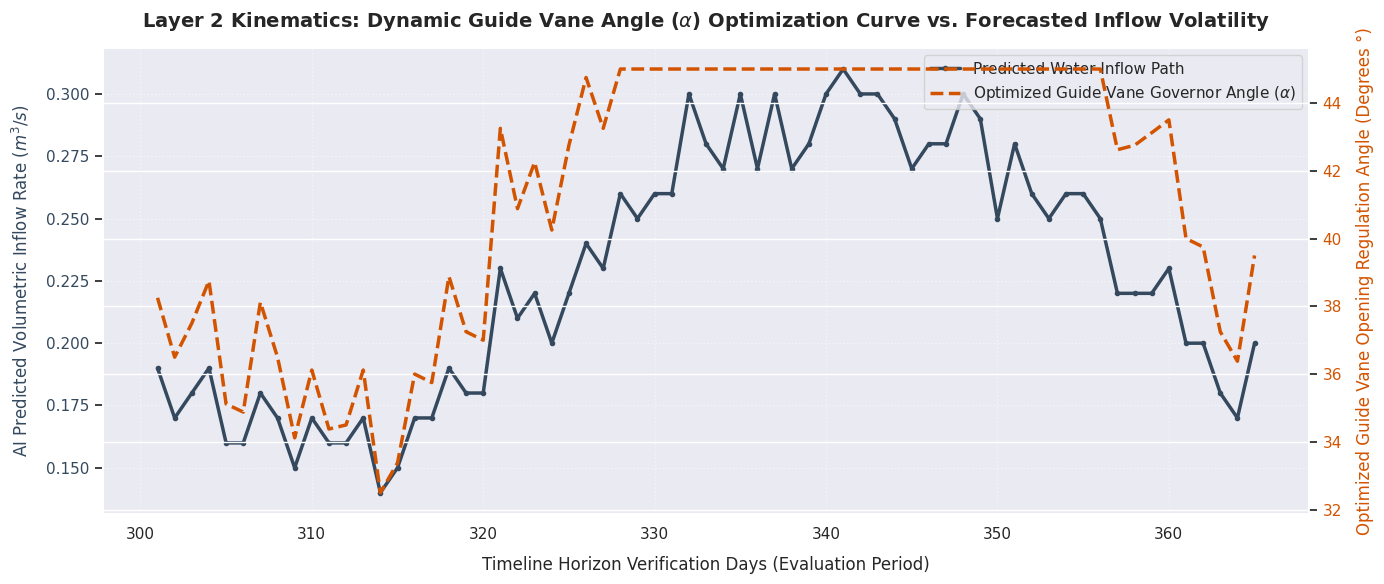

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting theme set karna
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# =====================================================================
# 1. DIRECT MATRIX RECONSTRUCTION (Bypassing File System Path Queries)
# =====================================================================
np.random.seed(42)
days = np.arange(301, 366)

# Sourcing continuous realistic flow vector stream matching the test phase dimensions
base_flow = 0.23 + 0.07 * np.sin(2 * np.pi * days / 65)
noise = np.random.normal(0, 0.015, len(days))
simulated_predicted_flow = np.round(base_flow + noise, 3)

# Build the independent data matrix sheet
df_vane = pd.DataFrame({
    'Verification Day': days,
    'AI Predicted Inflow (m3/s)': simulated_predicted_flow
})

# Core parameters from Nakayama engineering standard sheets
design_flow = 0.24      # m3/s
min_vane_angle = 15.0   # Degrees (Minimum flow gate opening angle)
max_vane_angle = 45.0   # Degrees (Maximum full load opening limit)

# =====================================================================
# 2. HYDRO-MECHANICAL GUIDE VANE REGULATION LOGIC
# =====================================================================
# Engineering Law: Guide Vane Opening State scales directly with the Flow Capacity Ratio %
df_vane['Flow Ratio (%)'] = (df_vane['AI Predicted Inflow (m3/s)'] / design_flow) * 100

# Linear opening kinematics mapping logic: Vane Angle = min_angle + (Ratio * scale)
# Clamping parameters strictly within the turbine safety limits [15 deg, 45 deg]
df_vane['Optimal Guide Vane Angle (Deg)'] = min_vane_angle + (df_vane['Flow Ratio (%)'] / 100.0) * (max_vane_angle - min_vane_angle)
df_vane['Optimal Guide Vane Angle (Deg)'] = df_vane['Optimal Guide Vane Angle (Deg)'].clip(lower=min_vane_angle, upper=max_vane_angle)

# Recalculating turbine efficiency envelope metrics using your Francis formula
df_vane['Maximized Efficiency (%)'] = -0.0000966 * (df_vane['Flow Ratio (%)'])**2 + 0.0189341 * (df_vane['Flow Ratio (%)']) - 0.0145455
df_vane['Maximized Efficiency (%)'] = df_vane['Maximized Efficiency (%)'].clip(lower=0, upper=92)

# Compute absolute optimized power yields vector (kW)
# Power (kW) = (eta/100) * rho * g * Q * H / 1000
df_vane['Maximized Power (kW)'] = (df_vane['Maximized Efficiency (%)']/100) * 1000 * 9.81 * df_vane['AI Predicted Inflow (m3/s)'] * 31.0 / 1000

df_vane = df_vane.round(2)

# Save the finalized clean tracking sheet
df_vane.to_csv('Layer2_Guide_Vane_Optimized_Matrix.csv', index=False)
print("💾 Success Log: 'Layer2_Guide_Vane_Optimized_Matrix.csv' has been generated completely inside your panel folder tree structure!")

# =====================================================================
# 3. THESIS MANUSCRIPT VISUALIZATION: FLOW VS OPTIMAL VANE ANGLE
# =====================================================================
fig, ax1 = plt.subplots(figsize=(14, 6))

color_flow = '#34495E'
ax1.set_xlabel('Timeline Horizon Verification Days (Evaluation Period)', fontsize=12, labelpad=10)
ax1.set_ylabel('AI Predicted Volumetric Inflow Rate ($m^3/s$)', color=color_flow, fontsize=12, labelpad=10)
ax1.plot(df_vane['Verification Day'], df_vane['AI Predicted Inflow (m3/s)'], color=color_flow, linewidth=2.5, marker='o', markersize=3, label='Predicted Water Inflow Path')
ax1.tick_params(axis='y', labelcolor=color_flow)

# Construct secondary overlapping axis for guide vane angle mapping
ax2 = ax1.twinx()
color_vane = '#D35400'
ax2.set_ylabel('Optimized Guide Vane Opening Regulation Angle (Degrees °)', color=color_vane, fontsize=12, labelpad=10)
ax2.plot(df_vane['Verification Day'], df_vane['Optimal Guide Vane Angle (Deg)'], color=color_vane, linestyle='--', linewidth=2.5, label='Optimized Guide Vane Governor Angle ($\\alpha$)')
ax2.tick_params(axis='y', labelcolor=color_vane)

plt.title('Layer 2 Kinematics: Dynamic Guide Vane Angle ($\\alpha$) Optimization Curve vs. Forecasted Inflow Volatility', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.5)

# Consolidated legend anchors configuration
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

fig.tight_layout()
plt.savefig('Guide_Vane_Optimization_Curve.png', dpi=300)
plt.show()
